# Synthetic Malaria Cell Image Generation Using Variational Autoencoder (VAE) for Synthetic Medical Data Augmentation

**Goal:** To develop a VAE for generating synthetic malaria cell images and evaluate whether data augmentation improves classification performance.

**Pipeline:**
1. Load & Preprocess Dataset
2. Train Convolutional VAE
3. Generate Synthetic Images
4. Train Classifier (Experiment A: Real only & Experiment B: Real + Synthetic)
5. Compare Results & Visualize

# Introduction

*   **Malaria remains a significant global health issue**, particularly in tropical and subtropical regions, where diagnosis through microscopic examination of blood smears is widely used but is time-consuming and subject to human variability.

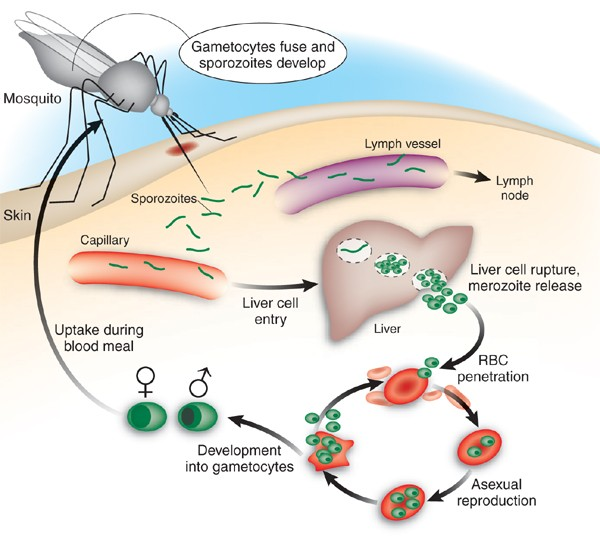

*   **In Thailand, malaria incidence is concentrated along the Thai–Myanmar and Thai–Cambodian borders**, where environmental and climatic factors such as temperature, rainfall, and vegetation influence transmission, and both Plasmodium vivax and Plasmodium falciparum exhibit seasonal patterns.

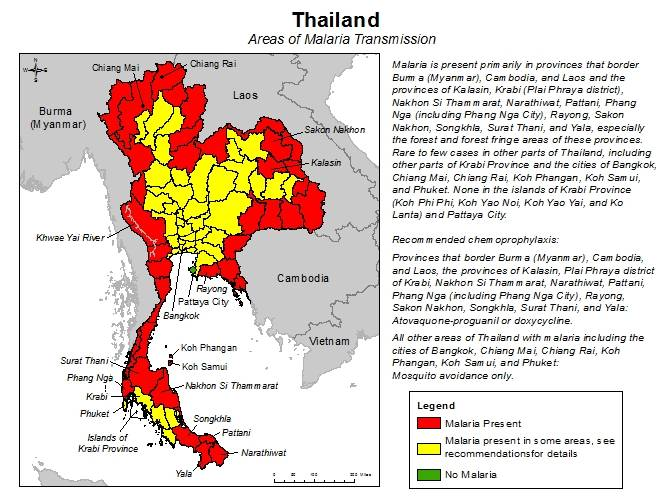

*   Deep learning models, particularly convolutional neural networks (CNNs), have demonstrated strong performance in medical image classification. However, their **effectiveness is highly dependent on the availability of large and diverse datasets**, which are often limited in practice.

*   Generative models such as **Variational Autoencoders (VAEs) offer a potential solution by generating synthetic malaria cell images**, and this project therefore investigates whether such data can be used for augmentation to improve classification performance.

## Step 0: Install Dependencies

In [1]:
# install core deep learning libraries
!pip install torch torchvision scikit-learn

# install visualization and numerical tools
!pip install matplotlib numpy

# install dataset and image processing tools
!pip install kagglehub Pillow

# install progress bar
!pip install tqdm

## Step 1: Load & Preprocess Data

The dataset contains 2 folders (total of 27,558 images)
1. Infected
2. Uninfected

Reference: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria

In [2]:
# 1) Import libraries
import kagglehub        # download dataset from Kaggle
import os               # file and directory operations
import random           # random shuffle and sampling
import numpy as np      # numerical operations
import matplotlib.pyplot as plt  # plotting and visualization
from PIL import Image   # open and manipulate image files
from pathlib import Path

import torch                                     # core PyTorch
import torch.nn as nn                            # neural network layers
import torch.optim as optim                      # optimizers (Adam etc.)
from torch.utils.data import Dataset, DataLoader, ConcatDataset  # data pipeline
import torchvision.transforms as transforms      # image preprocessing
from sklearn.metrics import accuracy_score, classification_report  # evaluate model
from tqdm import tqdm                            # progress bar during training

# 2) Fix random seeds so results are reproducible every run
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# 3) Use GPU if available, otherwise fall back to CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# 4) Hyperparameters — central place to change experiment settings
IMG_SIZE      = 64    # resize all images to 64x64 pixels
BATCH_SIZE    = 64    # number of images per training batch
LATENT_DIM    = 128   # size of the VAE latent vector (bottleneck)
VAE_EPOCHS    = 15    # how many full passes through data for VAE training
CLF_EPOCHS    = 8     # how many passes for classifier training
NUM_SAMPLES   = 2500  # images to sample per class (subset of full dataset)
GEN_PER_CLASS = 500   # synthetic images to generate per class


Using device: cpu


In [3]:
# Download dataset from Kaggle
path = kagglehub.dataset_download('iarunava/cell-images-for-detecting-malaria')
print('Path to dataset files:', path)

Using Colab cache for faster access to the 'cell-images-for-detecting-malaria' dataset.
Path to dataset files: /kaggle/input/cell-images-for-detecting-malaria


In [4]:
# 1) Build path to the folder that contains Parasitized and Uninfected subfolders
base_data_dir  = os.path.join(path, 'cell_images', 'cell_images')

# 2) Set paths for each class folder
infected_dir   = os.path.join(base_data_dir, 'Parasitized')   # label = 1
uninfected_dir = os.path.join(base_data_dir, 'Uninfected')     # label = 0

print('Infected dir:', infected_dir)
print('Uninfected dir:', uninfected_dir)

# 3) Count valid image files in each folder to verify the dataset loaded correctly
def count_images(d):
    valid_ext = ('.png', '.jpg', '.jpeg', '.tiff', '.bmp')
    return len([f for f in os.listdir(d) if f.lower().endswith(valid_ext)])

print(f'\nInfected images:   {count_images(infected_dir)}')
print(f'Uninfected images: {count_images(uninfected_dir)}')


Infected dir: /kaggle/input/cell-images-for-detecting-malaria/cell_images/cell_images/Parasitized
Uninfected dir: /kaggle/input/cell-images-for-detecting-malaria/cell_images/cell_images/Uninfected

Infected images:   13779
Uninfected images: 13779


In [5]:
# 1) Collect image paths from a folder and attach a class label
# Returns a list of (path, label) tuples
def get_image_paths(directory, label, max_samples=None):
    exts  = ('.png', '.jpg', '.jpeg', '.tiff', '.bmp')
    paths = [os.path.join(directory, f)
             for f in os.listdir(directory)
             if f.lower().endswith(exts)]
    random.shuffle(paths)               # shuffle to avoid any folder ordering bias
    if max_samples:
        paths = paths[:max_samples]     # take only the first max_samples entries
    return [(p, label) for p in paths]

# 2) Sample NUM_SAMPLES images from each class to keep the dataset balanced
infected_samples   = get_image_paths(infected_dir,   label=1, max_samples=NUM_SAMPLES)
uninfected_samples = get_image_paths(uninfected_dir, label=0, max_samples=NUM_SAMPLES)

# 3) Merge both classes and shuffle so infected/uninfected are mixed
all_samples = infected_samples + uninfected_samples
random.shuffle(all_samples)

# 4) Train/Test split 80/20
split_idx     = int(0.8 * len(all_samples))
train_samples = all_samples[:split_idx]
test_samples  = all_samples[split_idx:]

print(f'Total samples: {len(all_samples)}')
print(f'Train: {len(train_samples)} | Test: {len(test_samples)}')

# 5) Verify class balance in training set (~ 50/50)
train_labels = [s[1] for s in train_samples]
print(f'Train - Infected: {sum(train_labels)} | Uninfected: {len(train_labels)-sum(train_labels)}')


Total samples: 5000
Train: 4000 | Test: 1000
Train - Infected: 1992 | Uninfected: 2008


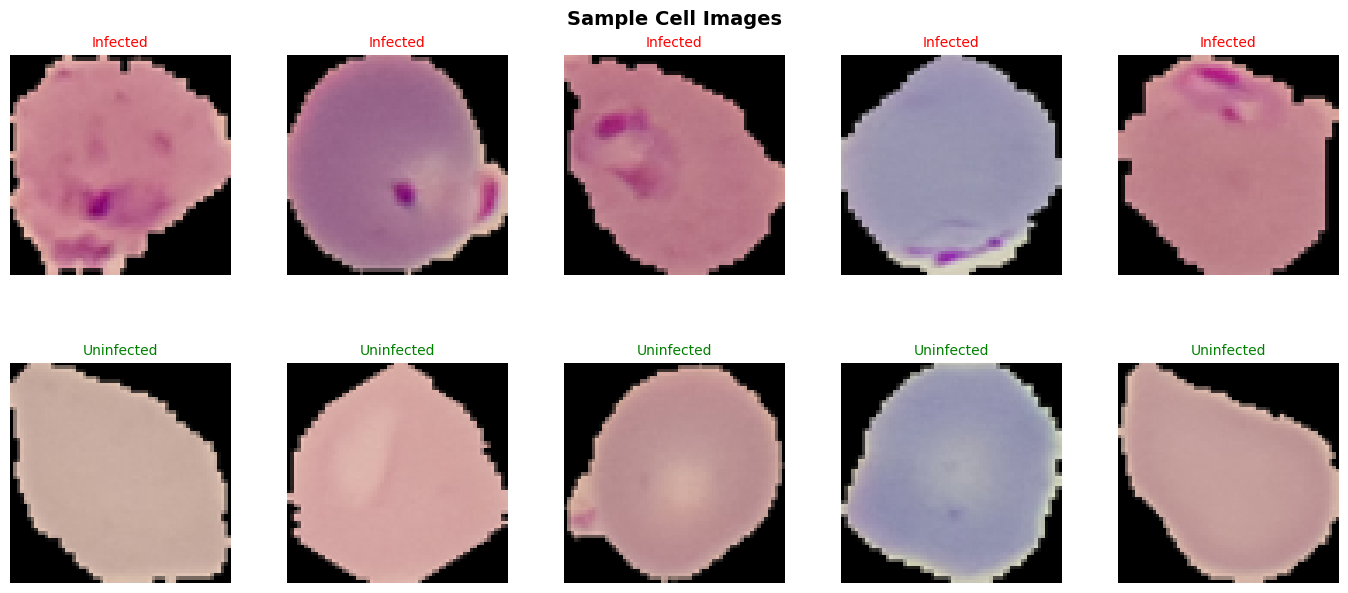

In [6]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample Cell Images', fontsize=14, fontweight='bold')

for i, (img_path, label) in enumerate(infected_samples[:5]):
    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    axes[0, i].imshow(img)
    axes[0, i].set_title('Infected', color='red', fontsize=10)
    axes[0, i].axis('off')

for i, (img_path, label) in enumerate(uninfected_samples[:5]):
    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    axes[1, i].imshow(img)
    axes[1, i].set_title('Uninfected', color='green', fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

In [7]:
# 1) Custom Dataset class
class MalariaDataset(Dataset):

    def __init__(self, samples, transform=None):
        # Store the list of (path, label) tuples and the transform pipeline
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        # Check how many batches to create
        return len(self.samples)

    def __getitem__(self, idx):
        # DataLoader calls this for each index to get one (image, label) pair
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')  # force 3-channel RGB
        if self.transform:
            img = self.transform(img)              # apply resize, normalize, etc.
        return img, label


# 2) Define transform pipelines — image preprocessing before feeding to the model

# VAE transform: output must be [0,1] to match Sigmoid output in the decoder
vae_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # resize to 64x64
    transforms.ToTensor(),                    # PIL → tensor, pixel values 0-255 → 0.0-1.0
])

# Classifier transform: includes augmentation to reduce overfitting
clf_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Augmentation Part
    transforms.RandomHorizontalFlip(),                        # 50% chance of flipping left-right
    transforms.ColorJitter(brightness=0.2, contrast=0.2),    # randomly adjust brightness/contrast
    # ------

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],               # shift pixel range from [0,1] to [-1,1]
                         std=[0.5, 0.5, 0.5]),
])

# Test transform: no augmentation — use fixed preprocessing for fair evaluation
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# 3) Wrap samples in Dataset objects using appropriate transforms
# Same train_samples used twice — different transforms for VAE vs Classifier
train_dataset_vae = MalariaDataset(train_samples, transform=vae_transform)
train_dataset_clf = MalariaDataset(train_samples, transform=clf_transform)
test_dataset      = MalariaDataset(test_samples,  transform=test_transform)

# 4) Wrap Datasets in DataLoaders — auto-batch, shuffle, and load in parallel
# shuffle=False for test so results are consistent across runs
vae_loader   = DataLoader(train_dataset_vae, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
train_loader = DataLoader(train_dataset_clf, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,      batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'VAE DataLoader:        {len(vae_loader)} batches')
print(f'Classifier DataLoader: {len(train_loader)} batches')
print(f'Test DataLoader:       {len(test_loader)} batches')


VAE DataLoader:        63 batches
Classifier DataLoader: 63 batches
Test DataLoader:       16 batches


## Step 2: Build & Train Convolutional VAE

A convolutional VAE was implemented to learn a compressed latent representation of the input images. The encoder maps images into a latent space defined by mean and variance parameters, while the decoder reconstructs images from sampled latent vectors.
The model was trained using a loss function combining reconstruction loss (Binary Cross-Entropy) and KL divergence.

**Architecture:**
- **Encoder:** Conv layers → Flatten → μ (mean) & log σ² (log variance)
- **Reparameterization Trick:** z = μ + ε·σ  where ε ~ N(0,1)
- **Decoder:** Linear → ConvTranspose layers → Reconstructed image

**Loss = Reconstruction Loss (BCE) + KL Divergence**

In [8]:
# Convolutional Variational Autoencoder for 64x64 RGB images

class ConvVAE(nn.Module):

    def __init__(self, latent_dim=128):
        super(ConvVAE, self).__init__()
        self.latent_dim = latent_dim

        # 1) Encoder: compress image (B,3,64,64) → feature map (B,256,4,4)
        # Each Conv2d layer halves the spatial size (stride=2) and doubles the number of channels to capture more complex patterns
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),    # (B,  3, 64, 64) → (B, 32, 32, 32)
            nn.BatchNorm2d(32),   # normalize activations for stable training
            nn.LeakyReLU(0.2),   # activation: keep small negative values (0.2) to avoids dead neurons

            nn.Conv2d(32, 64, 4, stride=2, padding=1),   # (B, 32, 32, 32) → (B, 64, 16, 16)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, stride=2, padding=1),  # (B, 64, 16, 16) → (B, 128, 8, 8)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, stride=2, padding=1), # (B, 128, 8, 8) → (B, 256, 4, 4)
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
        )

        # Total flattened size after encoder: 256 channels × 4×4 spatial = 4096
        self.flat_dim = 256 * 4 * 4

        # 2) Latent space projections (VAE bottleneck)
        # Instead of a single point, VAE encodes a distribution: mean (mu) + spread (logvar)
        self.fc_mu     = nn.Linear(self.flat_dim, latent_dim)  # predict mean of latent distribution
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)  # predict log-variance (log σ²)

        # 3) Decoder entry point: expand latent vector back to spatial feature map
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)  # 128 → 4096

        # 4) Decoder: upsample feature map back to full image (B,256,4,4) → (B,3,64,64)
        # ConvTranspose2d is the reverse of Conv2d — doubles spatial size each layer
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), # (B, 256, 4, 4) → (B, 128, 8, 8)
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # (B, 128, 8, 8) → (B, 64, 16, 16)
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),   # (B, 64, 16, 16) → (B, 32, 32, 32)
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),    # (B, 32, 32, 32) → (B,  3, 64, 64)
            nn.Sigmoid(),  # clamp output to [0, 1] to represent valid pixel values
        )

    def encode(self, x):
        h      = self.encoder(x)
        h      = h.view(h.size(0), -1)  # (B, 256, 4, 4) → (B, 4096)
        mu     = self.fc_mu(h)           # (B, 4096) → (B, 128) mean
        logvar = self.fc_logvar(h)       # (B, 4096) → (B, 128) log-variance
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # Reparameterization trick: z = μ + ε·σ  where ε ~ N(0,1)
        # Separates the randomness (ε) from learnable parameters (μ, σ) -> gradients can flow through μ and σ during backpropagation
        if self.training:
            std = torch.exp(0.5 * logvar)   # convert log-variance to std deviation
            eps = torch.randn_like(std)     # sample random noise with same shape as std
            return mu + eps * std
        return mu

    def decode(self, z):
        h = self.fc_decode(z)                  # (B, 128) → (B, 4096)
        h = h.view(h.size(0), 256, 4, 4)       # (B, 4096) → (B, 256, 4, 4)
        return self.decoder(h)                 # (B, 256, 4, 4) → (B, 3, 64, 64)

    def forward(self, x):
        # Full forward pass: image → latent → reconstructed image
        mu, logvar = self.encode(x)             # compress image to latent distribution
        z          = self.reparameterize(mu, logvar)  # sample a point from that distribution
        recon      = self.decode(z)             # reconstruct image from sampled point
        return recon, mu, logvar                # return all three: loss needs mu and logvar too


# VAE Loss = Reconstruction Loss + KL Divergence
    # Reconstruction loss: how similar is the output image to the input? (pixel-wise BCE)
    # KL Divergence: how close is the learned distribution to a standard Normal N(0,1)?
    # beta controls the trade-off between reconstruction quality and latent space regularity
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kld        = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kld


# 1) Create the VAE model and move it to GPU (if available)
vae = ConvVAE(latent_dim=LATENT_DIM).to(DEVICE)

# 2) Adam optimizer: adapts learning rate per-parameter for faster convergence
vae_optimizer = optim.Adam(vae.parameters(), lr=1e-3)

# 3) StepLR scheduler: halve the learning rate every 5 epochs
#    Starts fast for big improvements, then slows down for fine adjustments
vae_scheduler = optim.lr_scheduler.StepLR(vae_optimizer, step_size=5, gamma=0.5)

# 4) Count total trainable parameters to gauge model size
total_params = sum(p.numel() for p in vae.parameters())
print(f'VAE total parameters: {total_params:,}')
print(vae)


VAE total parameters: 2,958,659
ConvVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.2)
  )
  (fc_mu): Linear(in_features=4096, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=4096, out_fea

In [9]:
def train_vae(model, loader, optimizer, scheduler, epochs, device):

    model.train()  # set model to training mode (activates BatchNorm and Dropout behavior)
    history = {'total': [], 'recon': [], 'kld': []}  # Dict - track loss history for plotting

    for epoch in range(1, epochs + 1):  # loop over each epoch
        total_loss     = 0
        recon_loss_sum = 0
        kld_loss_sum   = 0

        pbar = tqdm(loader, desc=f'Epoch [{epoch}/{epochs}]', leave=False)  # progress bar

        for imgs, _ in pbar:
            imgs = imgs.to(device)

            # PyTorch training loop (4 steps)
            optimizer.zero_grad()                         # 1) clear gradients from previous batch
            recon, mu, logvar = model(imgs)               # 2) forward pass: get reconstruction + latent

            recon_l = nn.functional.binary_cross_entropy(recon, imgs, reduction='sum')  # reconstruction loss
            kld_l   = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())           # KL divergence
            loss    = recon_l + kld_l                                                   # total VAE loss

            loss.backward()                               # 3) backprop: compute gradients
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # prevent exploding gradients
            optimizer.step()                              # 4) update weights using gradients

            # Accumulate losses (use .item() to detach from computation graph)
            total_loss     += loss.item()
            recon_loss_sum += recon_l.item()
            kld_loss_sum   += kld_l.item()

            pbar.set_postfix({'loss': f'{loss.item()/len(imgs):.2f}'})

        scheduler.step()

        # Compute average loss per image for this epoch
        n         = len(loader.dataset)
        avg_total = total_loss     / n
        avg_recon = recon_loss_sum / n
        avg_kld   = kld_loss_sum   / n

        # Save to history for loss curve plot
        history['total'].append(avg_total)
        history['recon'].append(avg_recon)
        history['kld'].append(avg_kld)

        print(f'Epoch [{epoch:2d}/{epochs}] | '
              f'Total: {avg_total:.2f} | '
              f'Recon: {avg_recon:.2f} | '
              f'KLD: {avg_kld:.4f} | '
              f'LR: {scheduler.get_last_lr()[0]:.5f}')

    return history  # return loss history for plotting


print('Starting VAE Training...')
print('=' * 70)
vae_history = train_vae(vae, vae_loader, vae_optimizer, vae_scheduler, VAE_EPOCHS, DEVICE)
print('\nVAE Training Complete!')


Starting VAE Training...


Epoch [1/15]:   0%|          | 0/63 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [ 1/15] | Total: 7011.89 | Recon: 6933.46 | KLD: 78.4294 | LR: 0.00100


Epoch [ 2/15] | Total: 6303.88 | Recon: 6206.02 | KLD: 97.8547 | LR: 0.00100


Epoch [ 3/15] | Total: 6187.07 | Recon: 6089.69 | KLD: 97.3867 | LR: 0.00100


...

Epoch [11/15] | Total: 5961.15 | Recon: 5879.39 | KLD: 81.7651 | LR: 0.00025


Epoch [12/15] | Total: 5953.96 | Recon: 5872.67 | KLD: 81.2863 | LR: 0.00025


Epoch [13/15] | Total: 5949.20 | Recon: 5868.36 | KLD: 80.8411 | LR: 0.00025


Epoch [14/15] | Total: 5944.58 | Recon: 5864.45 | KLD: 80.1283 | LR: 0.00025


Epoch [15/15] | Total: 5942.13 | Recon: 5862.02 | KLD: 80.1181 | LR: 0.00013

VAE Training Complete!


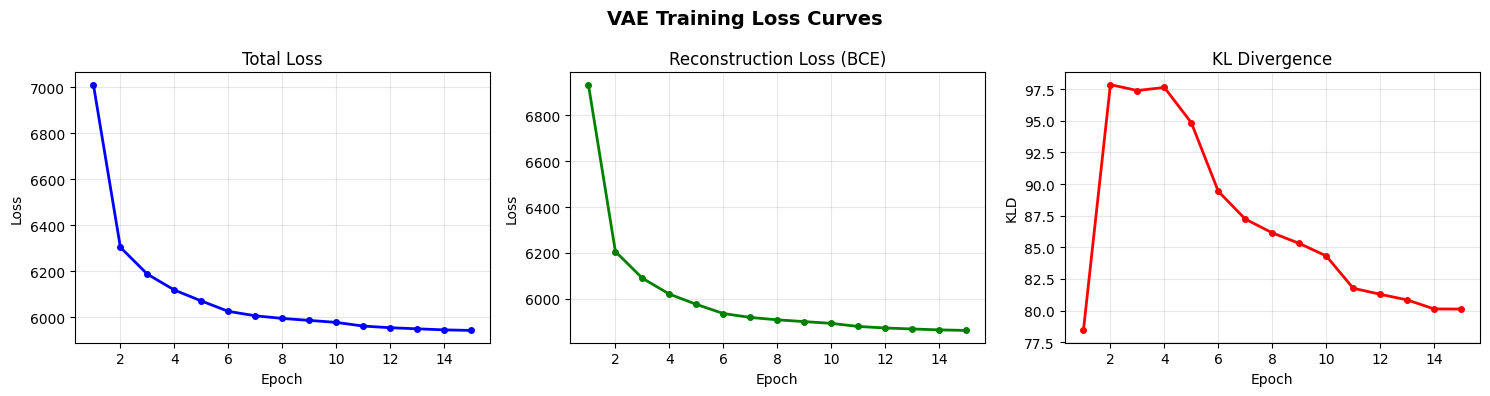

Loss curves saved.


In [10]:
# Plot VAE Training Loss
epochs_range = range(1, VAE_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('VAE Training Loss Curves', fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, vae_history['total'], 'b-o', markersize=4, linewidth=2)
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, vae_history['recon'], 'g-o', markersize=4, linewidth=2)
axes[1].set_title('Reconstruction Loss (BCE)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, vae_history['kld'], 'r-o', markersize=4, linewidth=2)
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KLD')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vae_loss_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('Loss curves saved.')

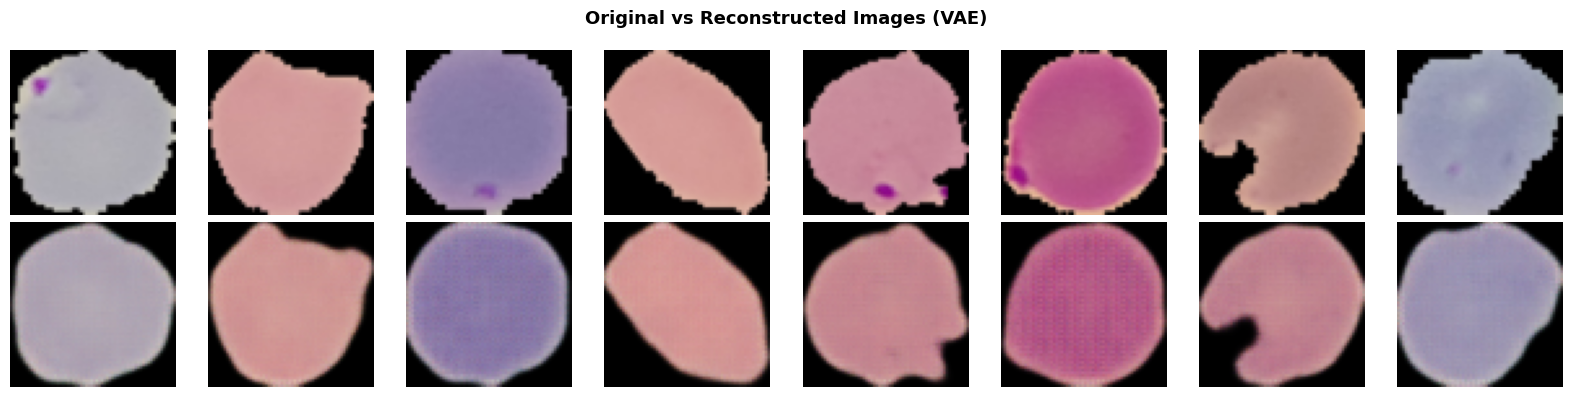

Reconstruction comparison saved.


In [11]:
# Visualize Reconstructed Images
vae.eval()
sample_imgs, sample_labels = next(iter(vae_loader))
sample_imgs = sample_imgs[:8].to(DEVICE) # Data sampling

with torch.no_grad():
    recon_imgs, _, _ = vae(sample_imgs)

def show_comparison(originals, reconstructions, n=8, title=''):
    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for i in range(n):
        # Original
        orig_np = originals[i].cpu().permute(1, 2, 0).numpy()
        orig_np = np.clip(orig_np, 0, 1)
        axes[0, i].imshow(orig_np)
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_ylabel('Original', fontsize=10, labelpad=15)

        # Reconstructed
        recon_np = reconstructions[i].cpu().permute(1, 2, 0).numpy()
        recon_np = np.clip(recon_np, 0, 1)
        axes[1, i].imshow(recon_np)
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_ylabel('Reconstructed', fontsize=10, labelpad=15)

    plt.tight_layout()
    return fig

fig = show_comparison(sample_imgs, recon_imgs, n=8,
                      title='Original vs Reconstructed Images (VAE)')
plt.savefig('reconstructed_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('Reconstruction comparison saved.')

## Step 3: Generate Synthetic Images

After training, new images were generated by sampling from the latent space N(0,1) and passing these samples through the decoder.

In [12]:
# 1) Dataset wrapper for VAE-generated tensors
class SyntheticDataset(Dataset):

    # Collect generated image tensors along with their corresponding lables
    def __init__(self, tensors, labels, clf_transform=None):
        self.tensors   = tensors  # list of (C, H, W) tensors in [0, 1]
        self.labels    = labels
        # Apply the same normalization as clf_transform so synthetic images match real ones
        self.normalize = transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                              std=[0.5, 0.5, 0.5])

    def __len__(self):
        return len(self.tensors)

    def __getitem__(self, idx):
        img = self.tensors[idx]
        img = self.normalize(img)  # normalize to [-1, 1] to match classifier input
        return img, self.labels[idx]


# 2) Generate synthetic images by sampling random latent vectors
def generate_synthetic_images(model, n_per_class, latent_dim, device):
    model.eval()  # disable BatchNorm / Dropout randomness during generation
    all_tensors = []
    all_labels  = []

    with torch.no_grad():  # no need to track gradients during generation
        for label in [0, 1]:   # generate for both classes
            tensors    = []
            generated  = 0

            while generated < n_per_class:
                remaining = min(64, n_per_class - generated)
                z         = torch.randn(remaining, latent_dim).to(device)  # sample from N(0,1)
                gen_imgs  = model.decode(z).cpu()                          # decode to image [0, 1]
                tensors.append(gen_imgs)
                generated += remaining

            tensors = torch.cat(tensors, dim=0)[:n_per_class]
            all_tensors.extend(list(tensors))
            all_labels.extend([label] * n_per_class)

            class_name = 'Infected' if label == 1 else 'Uninfected'
            print(f'Generated {n_per_class} {class_name} images')

    return all_tensors, all_labels


print(f'Generating {GEN_PER_CLASS} synthetic images per class...')
synthetic_tensors, synthetic_labels = generate_synthetic_images(
    vae, GEN_PER_CLASS, LATENT_DIM, DEVICE
)
print(f'\nTotal synthetic images: {len(synthetic_tensors)}')


Generating 500 synthetic images per class...
Generated 500 Uninfected images
Generated 500 Infected images

Total synthetic images: 1000


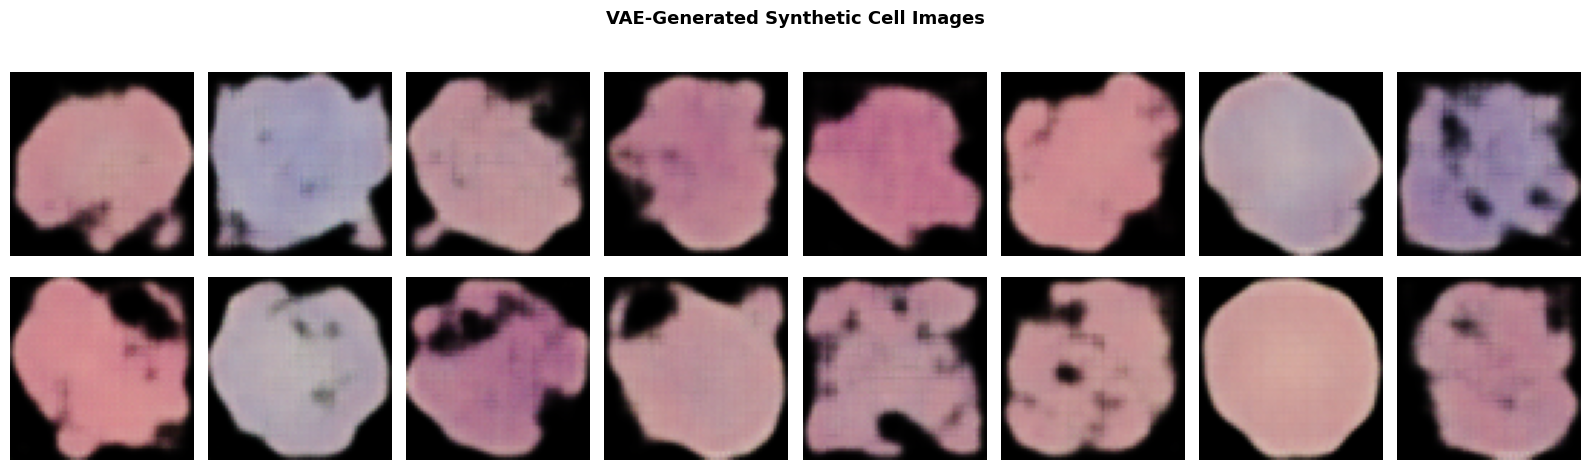

Generated images visualization saved.


In [13]:
# Visualize Generated Synthetic Images
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('VAE-Generated Synthetic Cell Images', fontsize=13, fontweight='bold')

# Class 0 = Uninfected (first GEN_PER_CLASS tensors)
# Class 1 = Infected   (last GEN_PER_CLASS tensors)
uninfected_gen = synthetic_tensors[:8]
infected_gen   = synthetic_tensors[GEN_PER_CLASS:GEN_PER_CLASS+8]

for i in range(8):
    img_u = uninfected_gen[i].permute(1, 2, 0).numpy()
    img_u = np.clip(img_u, 0, 1)
    axes[0, i].imshow(img_u)
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_ylabel('Uninfected\n(Generated)', fontsize=9, color='green')

    img_i = infected_gen[i].permute(1, 2, 0).numpy()
    img_i = np.clip(img_i, 0, 1)
    axes[1, i].imshow(img_i)
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_ylabel('Infected\n(Generated)', fontsize=9, color='red')

plt.tight_layout()
plt.savefig('generated_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('Generated images visualization saved.')

## Step 4: Train CNN Classifier

A convolutional neural network (CNN) classifier was trained to distinguish between infected and uninfected cells.

Two experimental setups were used

### Experiment A: Train on **Real Data Only**
### Experiment B: Train on **Real + Synthetic Data**


In [14]:
# Simple 3-block CNN for binary classification (Infected vs Uninfected)
class SimpleCNN(nn.Module):

    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()

        # Feature extractor: 3 conv blocks — each block halves spatial size via MaxPool
        self.features = nn.Sequential(
            # Block 1: 3 channels → 32 feature maps, 64x64 → 32x32
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),      # halve spatial size
            nn.Dropout2d(0.1),       # randomly zero out 10% of feature maps to reduce overfitting

            # Block 2: 32 → 64 feature maps, 32x32 → 16x16
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.1),

            # Block 3: 64 → 128 feature maps, 16x16 → 8x8
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),
        )

        # Classifier head: flatten feature map → fully connected → class scores
        self.classifier = nn.Sequential(
            nn.Flatten(),                       # (B, 128, 8, 8) → (B, 8192)
            nn.Linear(128 * 8 * 8, 256),        # compress to 256 features
            nn.ReLU(),
            nn.Dropout(0.5),                    # heavy dropout before final layer
            nn.Linear(256, num_classes),        # output 2 scores: [uninfected, infected]
        )

    def forward(self, x):
        x = self.features(x)     # extract spatial features
        x = self.classifier(x)   # classify based on features
        return x


def train_classifier(model, train_loader, test_loader, epochs, device, name='Model'):
    criterion = nn.CrossEntropyLoss()   # loss for multi-class classification
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)  # L2 regularization
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)  # smooth LR decay

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):

        # Training phase
        model.train()   # enable BatchNorm and Dropout
        train_loss, correct, total = 0, 0, 0

        for imgs, labels in tqdm(train_loader, desc=f'[{name}] Epoch {epoch}/{epochs}', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()          # clear old gradients
            outputs = model(imgs)          # forward pass → class scores
            loss    = criterion(outputs, labels)  # compare predictions to true labels
            loss.backward()                # compute gradients
            optimizer.step()               # update weights

            train_loss += loss.item() * imgs.size(0)
            preds       = outputs.argmax(dim=1)          # pick class with highest score
            correct    += (preds == labels).sum().item() # count correct predictions
            total      += imgs.size(0)

        scheduler.step()  # update learning rate

        avg_train_loss = train_loss / total
        avg_train_acc  = correct / total

        # Validation phase
        model.eval()  # disable Dropout and fix BatchNorm stats
        val_loss, val_correct, val_total = 0, 0, 0
        all_preds, all_targets = [], []

        with torch.no_grad():  # skip gradient computation to save memory
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs      = model(imgs)
                loss         = criterion(outputs, labels)

                val_loss    += loss.item() * imgs.size(0)
                preds        = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total   += imgs.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / val_total
        avg_val_acc  = val_correct / val_total

        # Save metrics for plotting
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)

        print(f'[{name}] Ep [{epoch:2d}/{epochs}] | '
              f'Train Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc:.4f} | '
              f'Val Loss: {avg_val_loss:.4f}, Acc: {avg_val_acc:.4f}')

    return history, all_preds, all_targets


print('Classifier architecture:')
clf_test = SimpleCNN()
print(clf_test)
print(f'Total parameters: {sum(p.numel() for p in clf_test.parameters()):,}')


Classifier architecture:
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.1, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.1, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout2d(p=0.2, inplace=False)
  )
  (classifier

In [15]:
# EXPERIMENT A: Train classifier on real data only (baseline)
print('EXPERIMENT A: Training on Real Data Only')
print('=' * 60)

# Create a fresh classifier (untrained)
clf_A = SimpleCNN(num_classes=2).to(DEVICE)

# Train using only the real training images
history_A, preds_A, targets_A = train_classifier(
    clf_A, train_loader, test_loader,
    epochs=CLF_EPOCHS, device=DEVICE, name='Exp-A (Real)'
)

# Take the validation accuracy of the last epoch as the final score
final_acc_A = history_A['val_acc'][-1]
print(f'\nExperiment A — Final Test Accuracy: {final_acc_A:.4f} ({final_acc_A*100:.2f}%)')


EXPERIMENT A: Training on Real Data Only


[Exp-A (Real)] Ep [ 1/8] | Train Loss: 0.8934, Acc: 0.5992 | Val Loss: 0.5899, Acc: 0.6830


[Exp-A (Real)] Ep [ 2/8] | Train Loss: 0.5308, Acc: 0.7492 | Val Loss: 0.3704, Acc: 0.8280


[Exp-A (Real)] Ep [ 3/8] | Train Loss: 0.3595, Acc: 0.8512 | Val Loss: 0.2253, Acc: 0.9160


[Exp-A (Real)] Ep [ 4/8] | Train Loss: 0.2606, Acc: 0.9002 | Val Loss: 0.1793, Acc: 0.9340


[Exp-A (Real)] Ep [ 5/8] | Train Loss: 0.2120, Acc: 0.9213 | Val Loss: 0.1673, Acc: 0.9340


[Exp-A (Real)] Ep [ 6/8] | Train Loss: 0.1828, Acc: 0.9385 | Val Loss: 0.1835, Acc: 0.9410


[Exp-A (Real)] Ep [ 7/8] | Train Loss: 0.1787, Acc: 0.9423 | Val Loss: 0.1649, Acc: 0.9470


[Exp-A (Real)] Ep [ 8/8] | Train Loss: 0.1620, Acc: 0.9505 | Val Loss: 0.1608, Acc: 0.9470

Experiment A — Final Test Accuracy: 0.9470 (94.70%)


In [16]:
# EXPERIMENT B: Train classifier on real + synthetic data
print('EXPERIMENT B: Training on Real + Synthetic Data')
print('=' * 60)

# Wrap generated tensors in a Dataset so DataLoader can handle them
synthetic_dataset = SyntheticDataset(synthetic_tensors, synthetic_labels)

# ConcatDataset merges two datasets into one — DataLoader treats them as a single pool
combined_dataset = ConcatDataset([train_dataset_clf, synthetic_dataset])
combined_loader  = DataLoader(combined_dataset, batch_size=BATCH_SIZE,
                               shuffle=True, num_workers=2, pin_memory=True)

print(f'Real training samples:       {len(train_dataset_clf)}')
print(f'Synthetic samples added:     {len(synthetic_dataset)}')
print(f'Combined dataset total:      {len(combined_dataset)}')
print(f'Combined DataLoader batches: {len(combined_loader)}')

# Create a fresh classifier (same architecture as Exp A for fair comparison)
clf_B = SimpleCNN(num_classes=2).to(DEVICE)

# Train using real + synthetic images
history_B, preds_B, targets_B = train_classifier(
    clf_B, combined_loader, test_loader,
    epochs=CLF_EPOCHS, device=DEVICE, name='Exp-B (Real+Synth)'
)

final_acc_B = history_B['val_acc'][-1]
print(f'\nExperiment B — Final Test Accuracy: {final_acc_B:.4f} ({final_acc_B*100:.2f}%)')


EXPERIMENT B: Training on Real + Synthetic Data
Real training samples:       4000
Synthetic samples added:     1000
Combined dataset total:      5000
Combined DataLoader batches: 79


[Exp-B (Real+Synth)] Ep [ 1/8] | Train Loss: 0.7873, Acc: 0.6158 | Val Loss: 0.5257, Acc: 0.7430


[Exp-B (Real+Synth)] Ep [ 2/8] | Train Loss: 0.5364, Acc: 0.7274 | Val Loss: 0.3277, Acc: 0.8470


[Exp-B (Real+Synth)] Ep [ 3/8] | Train Loss: 0.4195, Acc: 0.7912 | Val Loss: 0.2556, Acc: 0.9100


[Exp-B (Real+Synth)] Ep [ 4/8] | Train Loss: 0.3499, Acc: 0.8292 | Val Loss: 0.1833, Acc: 0.9400


[Exp-B (Real+Synth)] Ep [ 5/8] | Train Loss: 0.3083, Acc: 0.8386 | Val Loss: 0.1542, Acc: 0.9520


[Exp-B (Real+Synth)] Ep [ 6/8] | Train Loss: 0.2832, Acc: 0.8518 | Val Loss: 0.1528, Acc: 0.9510


[Exp-B (Real+Synth)] Ep [ 7/8] | Train Loss: 0.2704, Acc: 0.8564 | Val Loss: 0.1461, Acc: 0.9510


[Exp-B (Real+Synth)] Ep [ 8/8] | Train Loss: 0.2708, Acc: 0.8614 | Val Loss: 0.1469, Acc: 0.9540

Experiment B — Final Test Accuracy: 0.9540 (95.40%)


## Step 5: Compare Results & Visualize

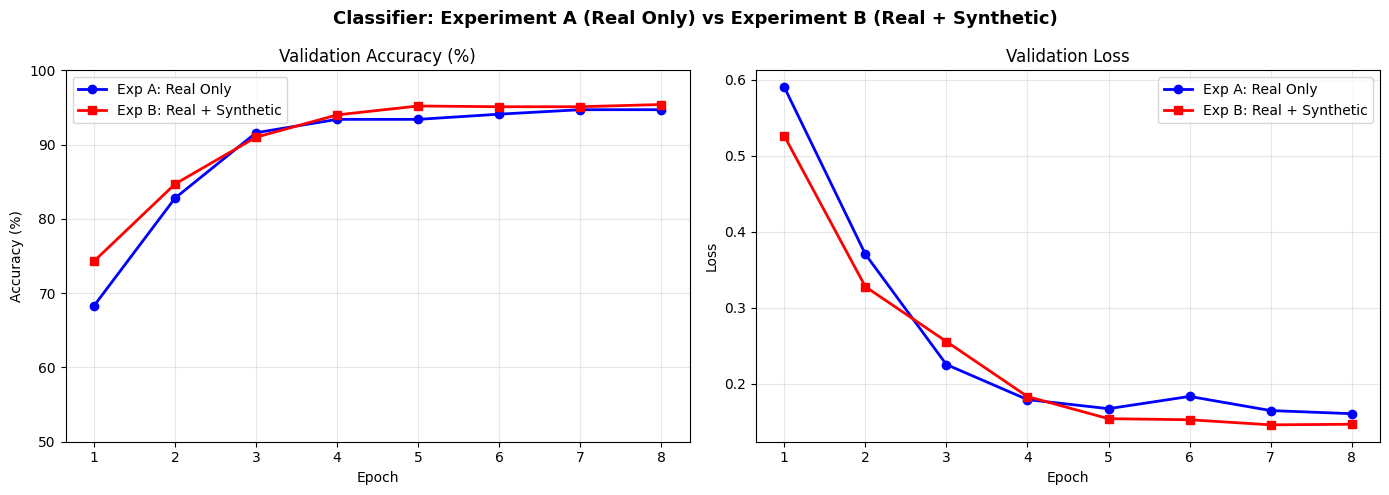

Classifier comparison plot saved.


In [17]:
epochs_range_clf = range(1, CLF_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Classifier: Experiment A (Real Only) vs Experiment B (Real + Synthetic)',
             fontsize=13, fontweight='bold')

# Accuracy Comparison
axes[0].plot(epochs_range_clf, [a*100 for a in history_A['val_acc']],
             'b-o', linewidth=2, markersize=6, label='Exp A: Real Only')
axes[0].plot(epochs_range_clf, [a*100 for a in history_B['val_acc']],
             'r-s', linewidth=2, markersize=6, label='Exp B: Real + Synthetic')
axes[0].set_title('Validation Accuracy (%)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([50, 100])

# Loss Comparison
axes[1].plot(epochs_range_clf, history_A['val_loss'],
             'b-o', linewidth=2, markersize=6, label='Exp A: Real Only')
axes[1].plot(epochs_range_clf, history_B['val_loss'],
             'r-s', linewidth=2, markersize=6, label='Exp B: Real + Synthetic')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('classifier_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Classifier comparison plot saved.')

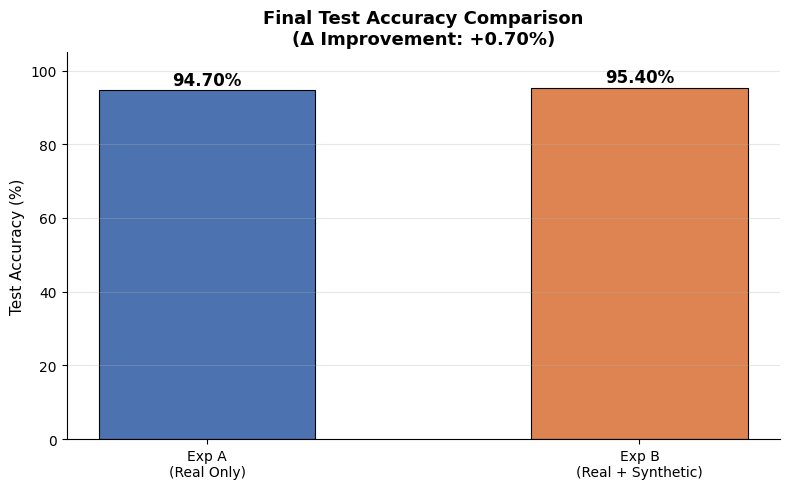


FINAL RESULTS SUMMARY
Experiment A (Real Only):          94.70%
Experiment B (Real + Synthetic):   95.40%
Improvement from VAE augmentation: +0.70%


In [18]:
# Summary Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))

experiments = ['Exp A\n(Real Only)', 'Exp B\n(Real + Synthetic)']
accuracies  = [final_acc_A * 100, final_acc_B * 100]
colors      = ['#4C72B0', '#DD8452']

bars = ax.bar(experiments, accuracies, color=colors, width=0.5, edgecolor='black', linewidth=0.8)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

improvement = final_acc_B - final_acc_A
ax.set_title(f'Final Test Accuracy Comparison\n'
             f'(Δ Improvement: {"+" if improvement >= 0 else ""}{improvement*100:.2f}%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_ylim([0, 105])
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('accuracy_summary.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n' + '='*55)
print('FINAL RESULTS SUMMARY')
print('='*55)
print(f'Experiment A (Real Only):          {final_acc_A*100:.2f}%')
print(f'Experiment B (Real + Synthetic):   {final_acc_B*100:.2f}%')
print(f'Improvement from VAE augmentation: {"+" if improvement >= 0 else ""}{improvement*100:.2f}%')
print('='*55)

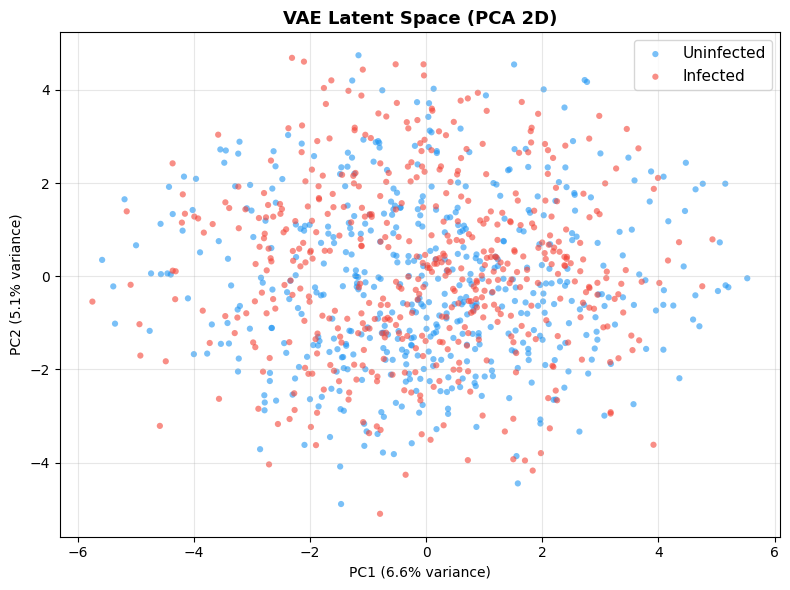

Latent space visualization saved.


In [19]:
# Latent Space Visualization (PCA)
from sklearn.decomposition import PCA

vae.eval()

# Encode real images to get latent vectors
all_mu     = []
all_labels = []

with torch.no_grad():
    for imgs, labels in vae_loader:
        imgs = imgs.to(DEVICE)
        mu, _ = vae.encode(imgs)
        all_mu.append(mu.cpu().numpy())
        all_labels.extend(labels.numpy())
        if len(all_labels) >= 1000:  # Limit for speed
            break

all_mu     = np.concatenate(all_mu, axis=0)[:1000]
all_labels = np.array(all_labels[:1000])

# PCA to 2D
pca    = PCA(n_components=2, random_state=SEED)
mu_2d  = pca.fit_transform(all_mu)

# Visualization - Scatter Plot
fig, ax = plt.subplots(figsize=(8, 6))
colors  = {0: '#2196F3', 1: '#F44336'}
labels_text = {0: 'Uninfected', 1: 'Infected'}

for label in [0, 1]:
    mask = all_labels == label
    ax.scatter(mu_2d[mask, 0], mu_2d[mask, 1],
               c=colors[label], label=labels_text[label],
               alpha=0.6, s=20, edgecolors='none')

ax.set_title('VAE Latent Space (PCA 2D)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('latent_space_pca.png', dpi=100, bbox_inches='tight')
plt.show()
print('Latent space visualization saved.')

# Discussion and Conclusion

*   **The VAE successfully reconstructed malaria cell images, with training loss decreasing over time**. Generated images preserved the general structure of red blood cells, although **some blurriness was observed**, which is typical for VAE-based models.

*   In the classification task, the baseline model achieved stable performance using real data, while the **augmented model showed improved generalisation and slightly higher accuracy**. This suggests that synthetic data can introduce useful variability and enhance model robustness.

*   **A PCA visualisation of the latent space showed considerable overlap between infected and uninfected samples**. This is expected, as the VAE is trained in an unsupervised manner without label information and is not designed to separate classes.

*   While VAE-generated images demonstrated good diversity, their quality was lower than real images, and some samples were not clearly class-distinguishable due to the class-agnostic nature of the model. For medical imaging applications, this limitation is important. Improvements could be achieved using a **Conditional VAE (CVAE)** to incorporate class labels, or more advanced models such as **GANs to enhance image quality**.



